# Fruit and Vegetable Freshness Classification — Model Comparison

This notebook summarizes results from the `src/` pipeline, describes preprocessing and the three architectures (M1/M2/M3), compares test metrics, visualizes learning curves/confusion matrices, and draws conclusions with EDA notes.

> This notebook reads artifacts from `results/` and `data/splits/`; it does not retrain. If evaluation hasn't been run, execute `python -m src.evaluate --model M1|M2|M3` first.

In [9]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

_candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next((p.resolve() for p in _candidates if (p / "src").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Project root with src/ not found. Open the notebook from the repository.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
RESULTS = ROOT / "results"
METRICS = RESULTS / "metrics"
PLOTS = RESULTS / "plots"
print(f"Project root: {ROOT}")

Project root: D:\EP16\Deep Neural Networks\DL-ImageClassification


## 1. Preprocessing Summary

- Images loaded as RGB; EXIF orientation normalized, alpha composited on fixed background.
- `ResizeWithPadding` produces square 128×128 (M1/M2) or 224×224 (M3) inputs without distortion.
- Train augmentation: horizontal flip, ±10° rotation, ColorJitter (brightness/contrast/saturation ±15%). Hue unchanged — color can be a freshness signal.
- Val/test: resize → tensor → ImageNet normalize.
- Stratified 70/15/15 split by SHA-256 groups, seed 42. Conflicting duplicates (same hash, different labels) excluded to prevent leakage.

See [`src/preprocessing.py`](../src/preprocessing.py) and [`src/data.py`](../src/data.py).

In [10]:
split_frames = {}
for split in ("train", "val", "test"):
    path = ROOT / "data" / "splits" / f"{split}.csv"
    if path.is_file():
        split_frames[split] = pd.read_csv(path)
if not split_frames:
    raise FileNotFoundError("No data/splits/*.csv found. Run python -m src.preprocessing first.")
split_sizes = pd.DataFrame({"split": list(split_frames), "images": [len(df) for df in split_frames.values()]})
display(split_sizes)
counts = pd.concat([df["class_name"].value_counts().rename(split) for split, df in split_frames.items()], axis=1).fillna(0).astype(int)
display(counts.head())
print(f"Total images: {int(split_sizes['images'].sum()):,}; classes: {counts.shape[0]}")

,split,images
0,train,20510
1,val,4381
2,test,4395


,train,val,test
class_name,,,
Apple__Rotten,2051,439,440
Banana__Rotten,1960,420,420
Apple__Healthy,1706,366,366
Mango__Rotten,1573,340,334
Orange__Rotten,1525,328,333


Total images: 29,286; classes: 28


### Notes from EDA

1. 28 classes (14 types × Healthy/Rotten) — accuracy alone is misleading; macro precision/recall/F1 gives each class equal weight.
2. Check class imbalance and visually similar classes (same type, different state). Review per-class F1 and confusion matrix together.
3. Variable size/aspect ratio and color mode justify RGB + padding over distorted resize. Corrupt/duplicate/conflicting images must be checked before splitting.
4. Color carries a freshness signal but is sensitive to lighting/background; keep augmentation light, no random hue. Be cautious about generalization beyond this dataset.
5. Hash-based splitting reduces leakage, but evaluation is on the same Kaggle domain — use an external test set for production.

## 2. Model Descriptions

| Model | Architecture | Input | Role |
|---|---|---:|---|
| **M1 – Simple NN** | Flatten → Linear 256 → ReLU/Dropout → Linear 128 → ReLU/Dropout → 28 logits | 128×128 | Baseline; ignores spatial structure |
| **M2 – Deep CNN** | 3 conv blocks (32/64/128 ch, BatchNorm, ReLU, MaxPool) → AdaptiveAvgPool → Dropout → Linear | 128×128 | Learns spatial features directly |
| **M3 – Transfer Learning** | MobileNetV2 pretrained, classifier replaced for 28 classes; freeze then fine-tune | 224×224 | Leverages ImageNet features, best accuracy |

M1/M2: Adam + weighted cross-entropy, checkpoint by val macro-F1. M3: train head first, then unfreeze backbone with lower LR. See [`src/train.py`](../src/train.py) and model files.

In [11]:
def load_json(path):
    return json.loads(path.read_text(encoding="utf-8")) if path.is_file() else None

models = ["M1", "M2", "M3"]
evaluation = {m: load_json(METRICS / f"{m}_evaluation.json") for m in models}
training = {m: load_json(METRICS / f"{m}_training.json") for m in models}
missing = [m for m in models if evaluation[m] is None]
if missing:
    print("Missing evaluation JSON for:", ", ".join(missing))
rows = []
for m in models:
    result = evaluation[m]
    if result:
        rows.append({"Model": m, "Accuracy": result["accuracy"], "Macro precision": result["macro_precision"], "Macro recall": result["macro_recall"], "Macro F1": result["macro_f1"]})
comparison = pd.DataFrame(rows).set_index("Model")
display(comparison.style.format("{:.4f}"))

,Accuracy,Macro precision,Macro recall,Macro F1
Model,,,,
M1,0.4253,0.3990,0.4815,0.3928
M2,0.7060,0.6493,0.7136,0.6583
M3,0.9832,0.9729,0.9766,0.9745


,Accuracy,Macro precision,Macro recall,Macro F1
Model,,,,
M1,0.4253,0.3990,0.4815,0.3928
M2,0.7060,0.6493,0.7136,0.6583
M3,0.9832,0.9729,0.9766,0.9745


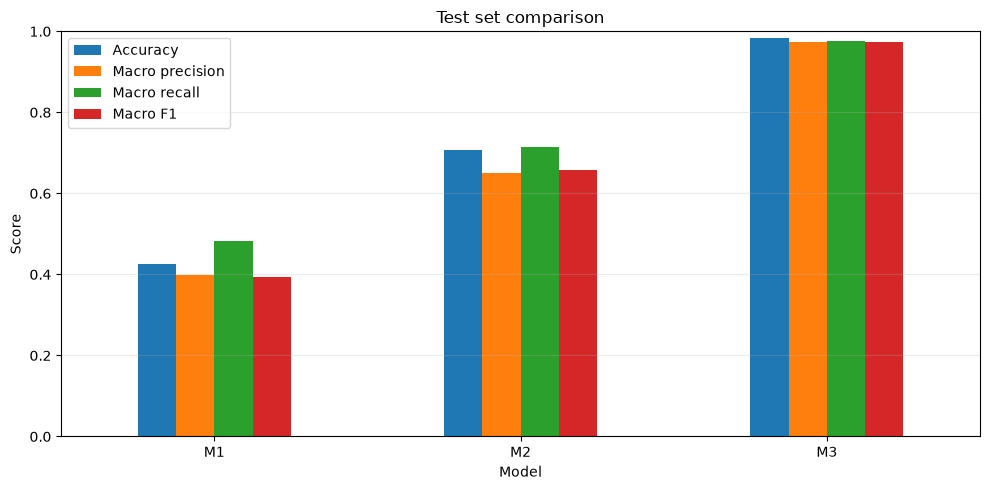

In [12]:
if comparison.empty:
    raise RuntimeError("No results found.")
display(comparison.style.format("{:.4f}").background_gradient(cmap="Blues"))
ax = comparison.plot(kind="bar", figsize=(10, 5), ylim=(0, 1), rot=0)
ax.set_ylabel("Score")
ax.set_title("Test set comparison")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

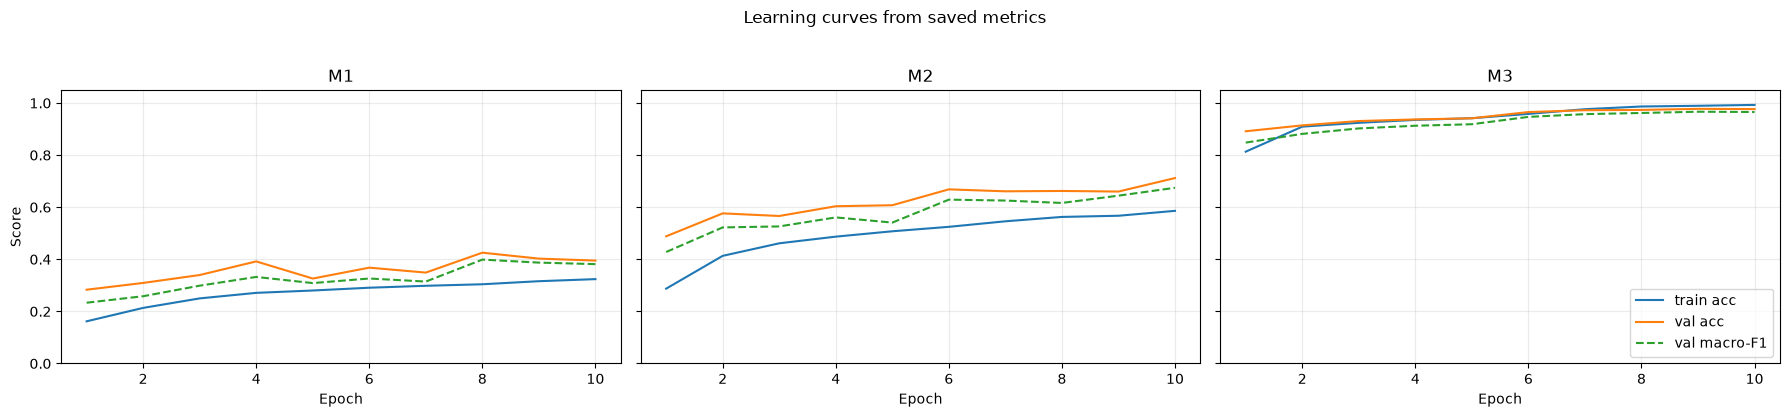

In [13]:
fig, axes = plt.subplots(1, len(models), figsize=(18, 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, model in zip(axes, models):
    history = training.get(model)
    if not history or not history.get("history"):
        ax.set_title(f"{model} (no history)")
        ax.axis("off")
        continue
    h = pd.DataFrame(history["history"])
    ax.plot(h["epoch"], h["train_accuracy"], label="train acc")
    ax.plot(h["epoch"], h["val_accuracy"], label="val acc")
    ax.plot(h["epoch"], h["val_macro_f1"], label="val macro-F1", linestyle="--")
    ax.set_title(model)
    ax.set_xlabel("Epoch")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Score")
axes[-1].legend(loc="lower right")
fig.suptitle("Learning curves from saved metrics", y=1.03)
plt.tight_layout()
plt.show()

## 3. Confusion Matrix & Per-Class Errors

Confusion matrix generated by [`src/evaluate.py`](../src/evaluate.py). Rows = true labels, columns = predicted labels; off-diagonal cells show commonly confused pairs.

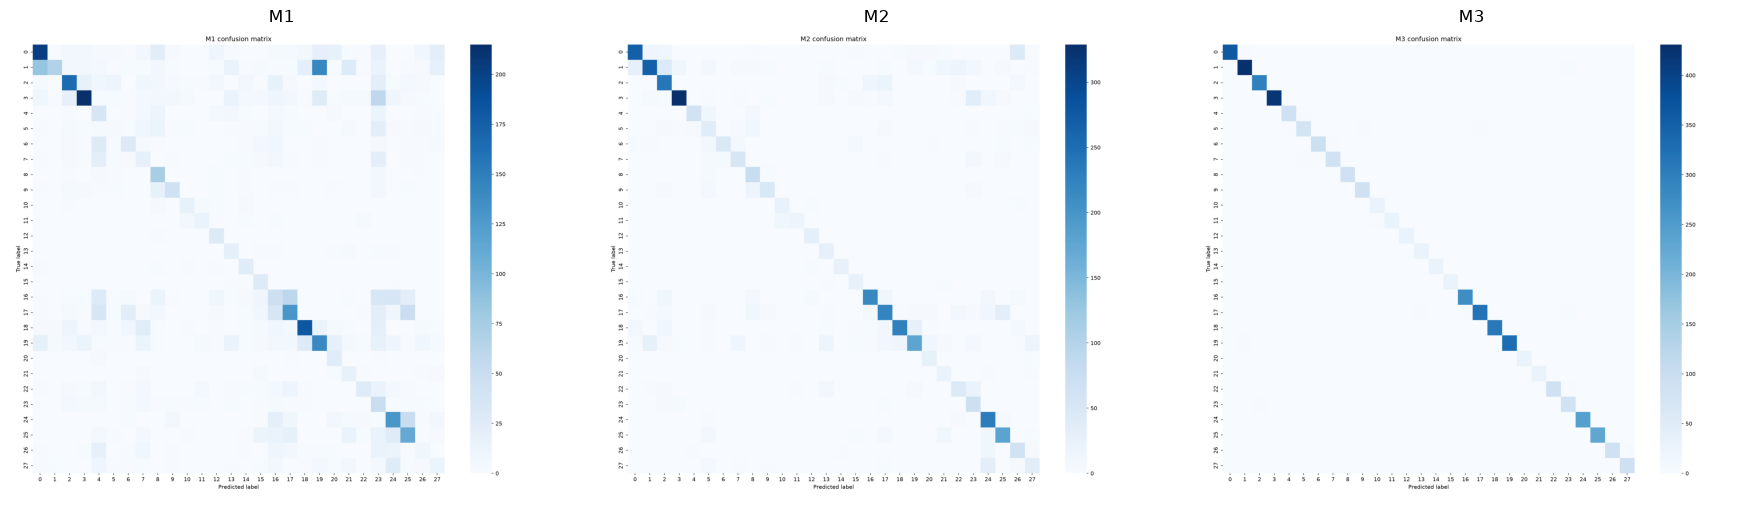

In [14]:
fig, axes = plt.subplots(1, len(models), figsize=(18, 5))
axes = np.atleast_1d(axes)
for ax, model in zip(axes, models):
    image_path = PLOTS / f"{model}_confusion_matrix.png"
    if image_path.is_file():
        ax.imshow(plt.imread(image_path))
        ax.set_title(model)
        ax.axis("off")
    else:
        ax.set_title(f"{model}: no image")
        ax.axis("off")
plt.tight_layout()
plt.show()

In [15]:
best_model = comparison["Macro F1"].idxmax()
best_report = evaluation[best_model].get("classification_report", {})
per_class = pd.DataFrame([
    {"class_name": name, "precision": values.get("precision", np.nan), "recall": values.get("recall", np.nan), "f1": values.get("f1-score", np.nan), "support": values.get("support", np.nan)}
    for name, values in best_report.items() if isinstance(values, dict) and "f1-score" in values
]).sort_values("f1")
print(f"Best model by test macro-F1: {best_model}")
display(per_class.head(10).style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}", "support": "{:.0f}"}))

Best model by test macro-F1: M3


,class_name,precision,recall,f1,support
23,Potato__Rotten,0.865,0.933,0.897,89
5,Bellpepper__Rotten,0.908,0.888,0.898,89
7,Carrot__Rotten,0.954,0.933,0.943,89
9,Cucumber__Rotten,0.944,0.977,0.960,87
4,Bellpepper__Healthy,0.957,0.967,0.962,91
11,Grape__Rotten,1.000,0.933,0.966,30
15,Jujube__Rotten,1.000,0.933,0.966,30
10,Grape__Healthy,0.938,1.000,0.968,30
13,Guava__Rotten,0.938,1.000,0.968,30
27,Tomato__Rotten,0.957,0.989,0.973,91


## 4. Conclusions

- **M3 is the best performer**: MobileNetV2 transfer learning achieves the highest macro-F1, clearly outperforming M2 and M1.
- **M2 improves significantly over baseline** thanks to convolution/pooling — spatial features matter for fruit/vegetable images.
- **M1 is suitable as a pipeline baseline**, but flattening destroys spatial structure; not recommended when quality matters.
- For deployment, don't rely on accuracy alone: track macro-F1, per-class recall, and off-diagonal confusion; prioritize low-F1 classes.
- Current results reflect the current checkpoint/split. Report latency/params/size if choosing by trade-off; validate on out-of-dataset photos before production.

In [16]:
best = comparison["Macro F1"].idxmax()
worst = comparison["Macro F1"].idxmin()
summary = (
    f"By test macro-F1, {best} leads ({comparison.loc[best, 'Macro F1']:.4f}), "
    f"{worst} trails ({comparison.loc[worst, 'Macro F1']:.4f}). "
    "Read this alongside per-class report and confusion matrix."
)
print(summary)

By test macro-F1, M3 leads (0.9745), M1 trails (0.3928). Read this alongside per-class report and confusion matrix.
